# 2: Dataset and indexing

In [71]:
%pip install numpy
%pip install pandas
%pip install matplotlib.pyplot
%pip install python-terrier

ERROR: Could not find a version that satisfies the requirement matplotlib.pyplot (from versions: none)
ERROR: No matching distribution found for matplotlib.pyplot


In [72]:
# Top-level imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyterrier as pt

In [73]:
# import docs
base = 'https://raw.githubusercontent.com/Legenden84/search-engines/master/project_handout/lab_files'

docs    = pd.read_json(f'{base}/docs2.jsonl', lines=True, dtype={'docno': str})
queries = pd.read_csv(f'{base}/train_queries.csv')
qrels   = pd.read_csv(f'{base}/train_qrels.csv')

In [74]:
print(docs.shape)
docs.sample(5, random_state=42)

(151993, 2)


,docno,text
114980,D114980,Leaning Tower of Pisa The tower's tilt began d...
88715,D88715,Under the Dome (novel) The semi-organized resi...
38065,D38065,"The First Time Ever I Saw Your Face ""The First..."
16042,D16042,Pretty Little Liars Virtually all these locati...
49231,D49231,"I Say a Little Prayer ""I Say a Little Prayer"" ..."


In [75]:
print(docs['text'].iloc[2115])

My Cousin Rachel (1952 film) Twentieth Century-Fox obtained the rights to film the novel, with Burton agreeing to star in a U.S. film for the first time. Production was troubled when du Maurier and original director George Cukor were dissatisfied with the adaptation, causing Cukor to leave the project.


In [76]:
print(queries.shape)
queries.sample(5)

(10000, 2)


,qid,text
314,314,the holder of this passport is not entitled to...
3873,3873,glass blowing is a technique that dates from r...
7178,7178,what is the meaning of penance in the catholic...
2426,2426,do you have to be 18 to go to a shooting range
3913,3913,in quebec which bill of rights takes precedenc...


In [77]:
print(qrels.shape)
qrels.sample(5)

(17746, 4)


,qid,docno,relevance,iteration
13552,3138,D116415,2,0
6708,8206,D58444,1,0
2171,3058,D19130,2,0
4973,2334,D43232,2,0
7241,4336,D63228,2,0


In [78]:
print('Unique labels: \n', qrels['relevance'].unique())
print('\n')
print('Distribution of labels: \n', qrels[['qid','relevance']].groupby(by='relevance').count().reset_index())

Unique labels: 
 [2 1]


Distribution of labels: 
    relevance    qid
0          1   7746
1          2  10000


In [79]:
print(qrels[qrels['relevance'] == 2])

        qid    docno  relevance  iteration
0       312      D15          2          0
1      6746      D31          2          0
2       272      D34          2          0
4      5963      D81          2          0
5      7532      D82          2          0
...     ...      ...        ...        ...
17739  1662  D151933          2          0
17740  4884  D151939          2          0
17742  2052  D151960          2          0
17744  3489  D151981          2          0
17745  4835  D151987          2          0

[10000 rows x 4 columns]


In [80]:
qid = 8030

# Sneak peak into the query for qid D127677
qrels_for_qid = qrels[qrels['qid'] == qid]
print(qrels_for_qid)

# Sneak peak into document highly relevant for qid D127677
print('\nQuery')
print(queries.loc[queries['qid'] == qid, 'text'].iloc[0])

# Sneak peak into document somwwhat relevant for qid D127677
docno = qrels_for_qid.sort_values('relevance', ascending=False)['docno'].iloc[0]

print(f'\nRelevant document for qid {qid}: {docno}')
print(docs.loc[docs["docno"] == docno, "text"].iloc[0])

        qid    docno  relevance  iteration
14880  8030  D127677          2          0

Query
what was the first hotel casino in las vegas

Relevant document for qid 8030: D127677
Prem Ratan Dhan Payo Prem Ratan Dhan Payo (English: Found a Treasure Called Love) is a 2015 Indian romantic drama film[4] written and directed by Sooraj Barjatya, produced by Rajshri Productions and distributed by Fox Star Studios. It stars Salman Khan and Sonam Kapoor in lead roles.[5] This is the fourth collaboration between Barjatya and Khan after their previous films Maine Pyar Kiya, Hum Aapke Hain Koun..!, and Hum Saath Saath Hain.


In [81]:
# Statistics
queries = queries["text"].str.split().str.len()
docs = docs["text"].str.split().str.len()

res = pd.DataFrame({
    "min": [queries.min(), docs.min()],
    "max": [queries.max(), docs.max()],
    "median": [queries.median(), docs.median()],
    "average": [queries.mean(), docs.mean()]
}, index=["queries", "documents"])

res

,min,max,median,average
queries,5,23,9.0,9.080600
documents,1,2219,82.0,91.458784


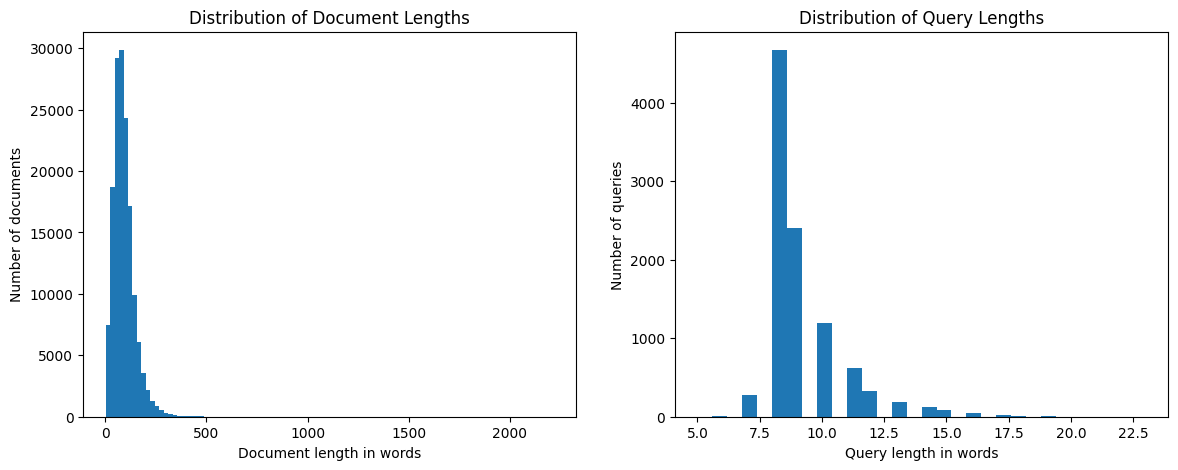

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Document length distribution
axes[0].hist(docs, bins=100)
axes[0].set_title("Distribution of Document Lengths")
axes[0].set_xlabel("Document length in words")
axes[0].set_ylabel("Number of documents")

# Query length distribution
axes[1].hist(queries, bins=30)
axes[1].set_title("Distribution of Query Lengths")
axes[1].set_xlabel("Query length in words")
axes[1].set_ylabel("Number of queries")

# plt.tight_layout()
plt.show()